In [1]:
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.colors as mcolors

from itertools import combinations

import itertools

def pcolormesh_45deg(ax, matrix_c, start_pos_vector, start, end):
    
    n = matrix_c.shape[0]
    # create rotation/scaling matrix
    t = np.array([[1, 0.5], [-1, 0.5]])
    # create coordinate matrix and transform it
    matrix_a = np.dot(np.array([(i[1], i[0])
                                for i in itertools.product(start_pos_vector[::-1],
                                                            start_pos_vector)]), t)
    
    # this is to convert the indices into bp ranges
    x = matrix_a[:, 1].reshape(n , n )
    y = matrix_a[:, 0].reshape(n , n )
    
    cmap = plt.cm.Reds#coolwarm
    norm = mcolors.TwoSlopeNorm(vmin=0, vcenter=5, vmax=10) #vcenter=0.7,

    #plt.imshow(hic_data[:,:], cmap=cmap,norm=norm,  interpolation='nearest')
    
    
    im = ax.pcolormesh(x, y, np.flipud(matrix_c), cmap=cmap,norm=norm)
    
    ax.set_xticks([-0.5,n+0.5])
    ax.set_xticklabels([start, end], fontsize=25)
    ax.tick_params(axis='x',which='major',direction='out',bottom=True,length=6, width = 1)
    
    ax.set_ylim(0, n)
    
    ax.xaxis.set_ticks_position('bottom') 
    #ax.tick_params(length=6, width=2, direction='inout')
    
    # Hide y-axis
    # Hide y-axis and spines
    ax.get_yaxis().set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)   
    
    return im


matrix_size = 10
matrix_data = np.random.rand(matrix_size, matrix_size)

def plot_hic_tri(matrix_data, start, end):
    
    matrix_size = matrix_data.shape[0]
    
    triangle_matrix = np.triu(matrix_data)

    # 创建一个掩码，将下半部分设为 False
    mask = np.tri(matrix_size, k=-1)
    masked_matrix = np.ma.array(triangle_matrix, mask=mask)

    fig, axs = plt.subplots(1, 1, figsize=(14, 6))


    # 调用 pcolormesh_45deg() 方法绘制旋转后的矩阵
    im = pcolormesh_45deg(axs, masked_matrix, np.arange(matrix_size), start, end)

    
    
    cbar = plt.colorbar(im)

    # 设置颜色条标签字体大小为12
    cbar.ax.tick_params(labelsize=25)
    
    plt.tight_layout()
    
    
    plt.savefig("chr14_76-81_hic.png",dpi=300)
    plt.show()


In [2]:
import pickle

chr_name = "chr14"

with open("chrom_data/GM12878/"+chr_name+"_sliding_data","rb") as f:
    sliding_data = pickle.load(f)

/public/home/wuyy/miniconda3/envs/torch/lib/python3.8/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
with open("chrom_data/GM12878/sliding_index","rb") as f:
    annotate = pickle.load(f)
    
anno = annotate["chr14"]

In [13]:
anno[12][0]*5000 #start

76020000

In [14]:
anno[12][-1]*5000 #end

81015000

In [15]:
data = sliding_data[12]

In [16]:
f = np.full((1000, 1000), np.nan)

# plot hic
for i in range(0,data.edge_index.shape[1]):
    k0 = data.edge_index[0,i]
    k1 = data.edge_index[1,i]
    f[k0, k1] = data.edge_attr[i]

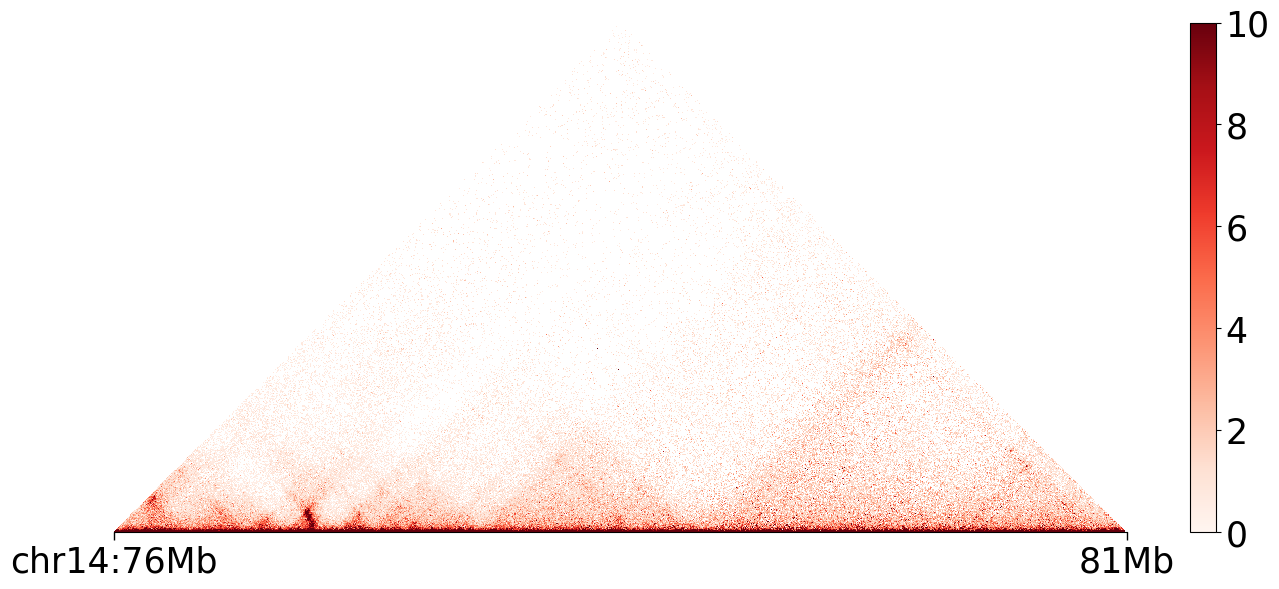

In [17]:
plot_hic_tri(f, 'chr14:76Mb', '81Mb')

In [18]:
from itertools import combinations

results = data.hyper_edge

res = []
for i in range(0,len(results)):
    r = results[i]
    for (a1, a2) in combinations(r, 2):
        res.append([a1,a2,1])

f = np.full((1000, 1000), np.nan)

res_dict = {}

for r in res:
    if (r[0],r[1]) in res_dict.keys():
        res_dict[(r[0],r[1])].append(r[2])
        res_dict[(r[1],r[0])].append(r[2])
    else:
        res_dict[(r[0],r[1])] = [r[2]]
        res_dict[(r[1],r[0])] = [r[2]]

for k, v in res_dict.items():
    f[k[0],k[1]] = np.sum(v)

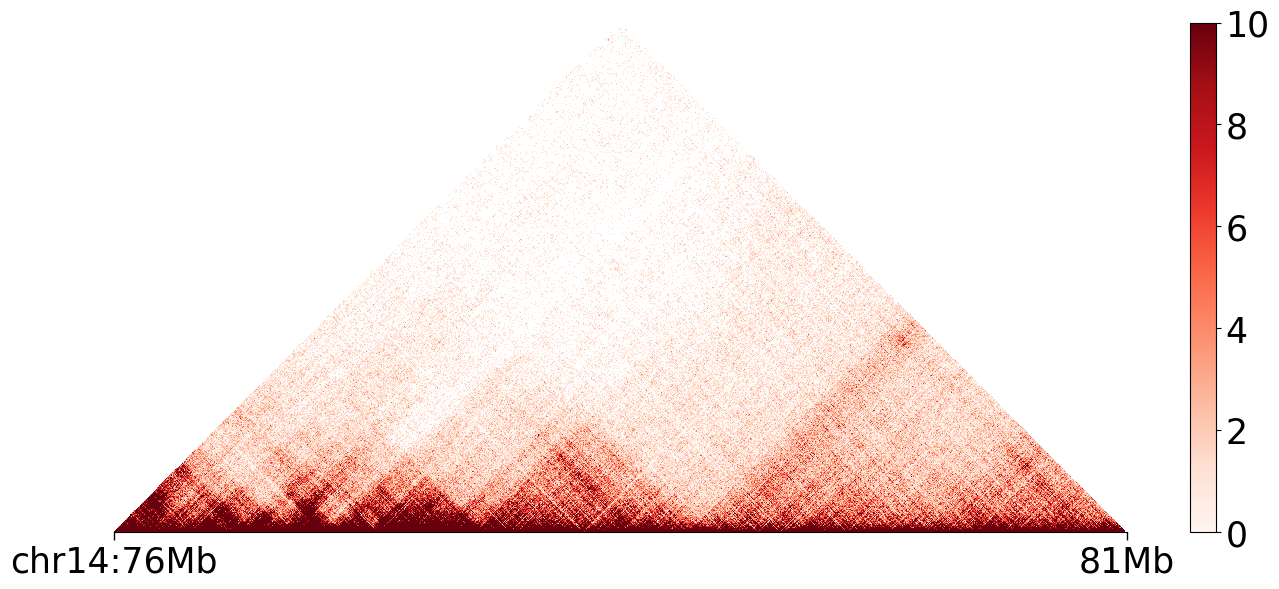

In [19]:
# plot pore_c
plot_hic_tri(f, 'chr14:76Mb', '81Mb')

In [20]:
results = data.sns

res = []
for i in range(0,len(results)):
    r = results[i]
    for (a1, a2) in combinations(r, 2):
        res.append([a1,a2,1])

In [21]:
f = np.full((1000, 1000), np.nan)

res_dict = {}

for r in res:
    if (r[0],r[1]) in res_dict.keys():
        res_dict[(r[0],r[1])].append(r[2])
        res_dict[(r[1],r[0])].append(r[2])
    else:
        res_dict[(r[0],r[1])] = [r[2]]
        res_dict[(r[1],r[0])] = [r[2]]

for k, v in res_dict.items():
    f[k[0],k[1]] = np.sum(v)

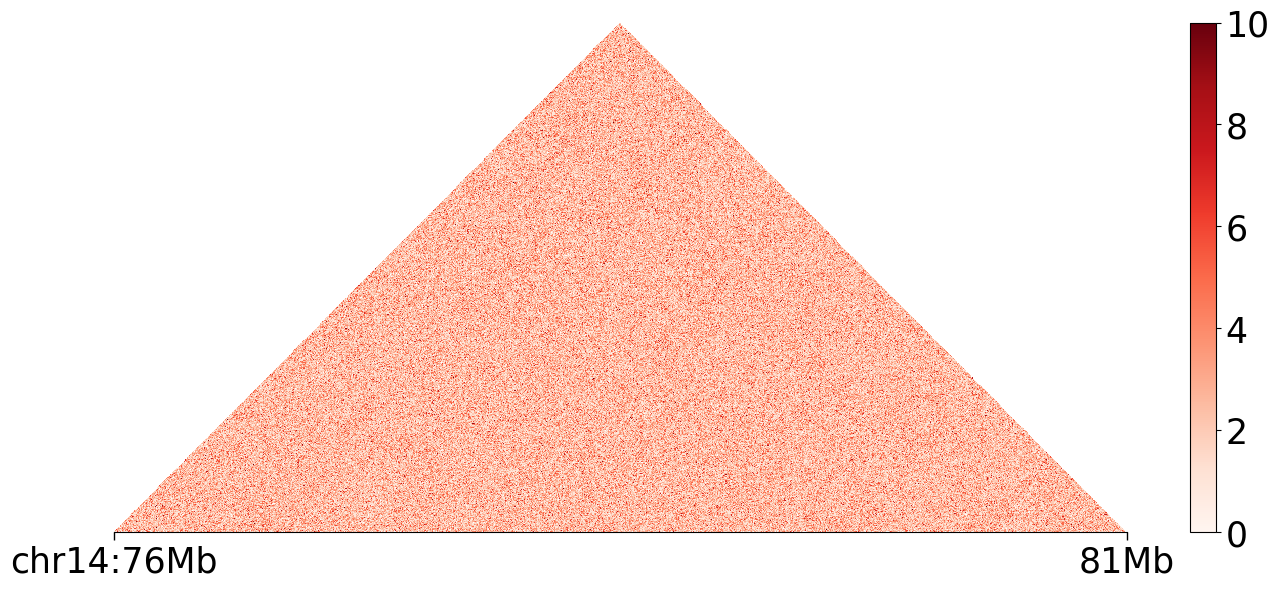

In [22]:
#plot sns
plot_hic_tri(f, 'chr14:76Mb', '81Mb')

In [23]:
results = data.mns

res = []
for i in range(0,len(results)):
    r = results[i]
    for (a1, a2) in combinations(r, 2):
        res.append([a1,a2,1])

In [24]:
f = np.full((1000, 1000), np.nan)

res_dict = {}

for r in res:
    if (r[0],r[1]) in res_dict.keys():
        res_dict[(r[0],r[1])].append(r[2])
        res_dict[(r[1],r[0])].append(r[2])
    else:
        res_dict[(r[0],r[1])] = [r[2]]
        res_dict[(r[1],r[0])] = [r[2]]

for k, v in res_dict.items():
    f[k[0],k[1]] = np.sum(v)

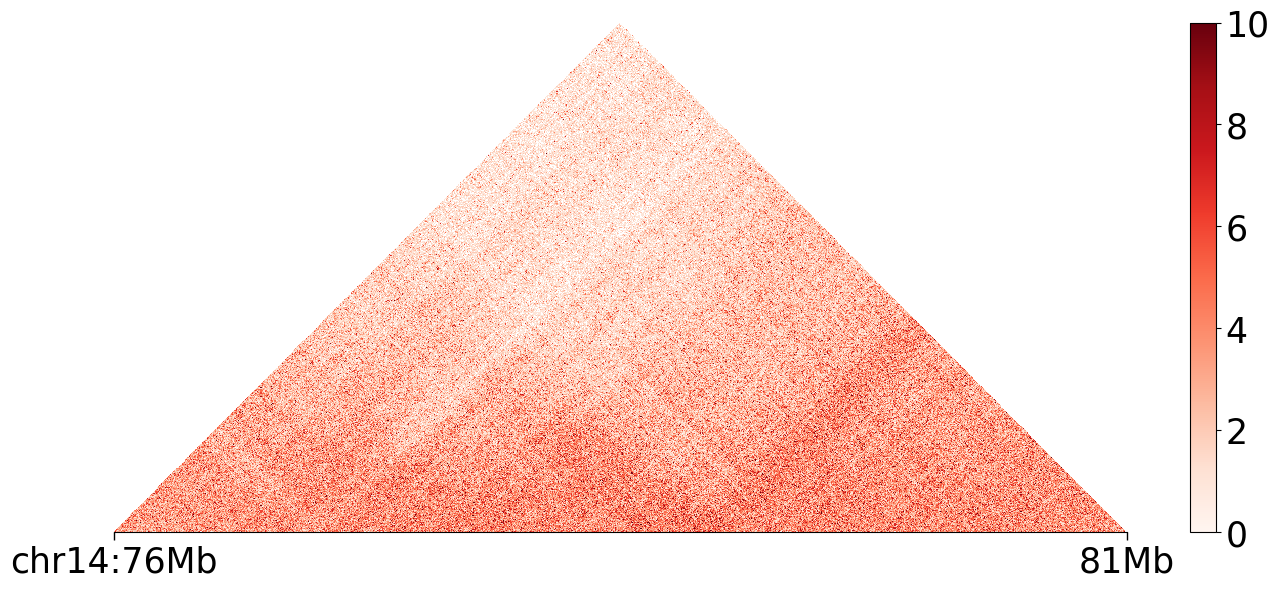

In [25]:
#plot mns
plot_hic_tri(f, 'chr14:76Mb', '81Mb')

In [26]:
results = data.cns

res = []
for i in range(0,len(results)):
    r = results[i]
    for (a1, a2) in combinations(r, 2):
        res.append([a1,a2,1])

In [27]:
f = np.full((1000, 1000), np.nan)

res_dict = {}

for r in res:
    if (r[0],r[1]) in res_dict.keys():
        res_dict[(r[0],r[1])].append(r[2])
        res_dict[(r[1],r[0])].append(r[2])
    else:
        res_dict[(r[0],r[1])] = [r[2]]
        res_dict[(r[1],r[0])] = [r[2]]

for k, v in res_dict.items():
    f[k[0],k[1]] = np.sum(v)

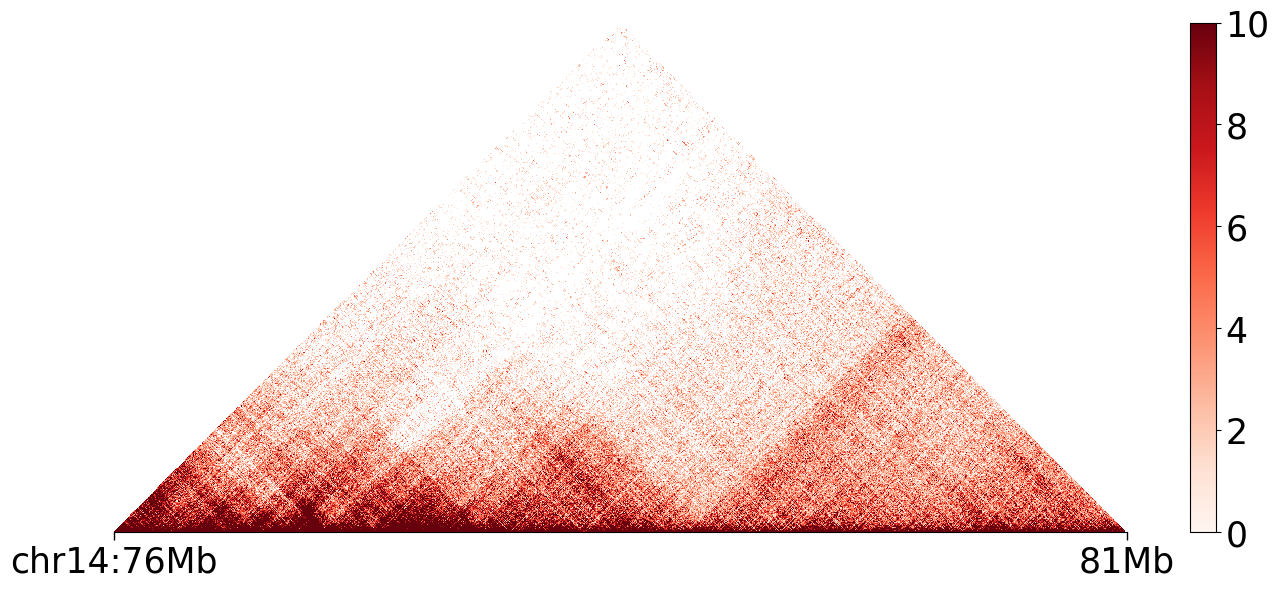

In [28]:
#plot cns
plot_hic_tri(f, 'chr14:76Mb', '81Mb')